In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 1. Завантаження даних (заміни 'your_dataset.csv' на реальну назву файлу)

TRAIN_FILE = "./raw_data/data-1774627968260.csv" 

df = pd.read_csv(TRAIN_FILE)

In [6]:
# Припустимо, колонки називаються: 'cpu', 'rps', 'ram'
# 2. Робимо трансформації
df['cpu_utilization'] = df['input_cpu'] / 2  # Приведення до бази 1000 або 100%
df['ptc_cpu'] = df['cpu_utilization'].pct_change()
df['ptc_rps'] = df['input_rps'].pct_change()
df['ptc_ram'] = df['input_ram'].pct_change()

In [7]:
# Очищуємо від NaN (перший рядок після pct_change завжди NaN)
df.dropna(inplace=True)

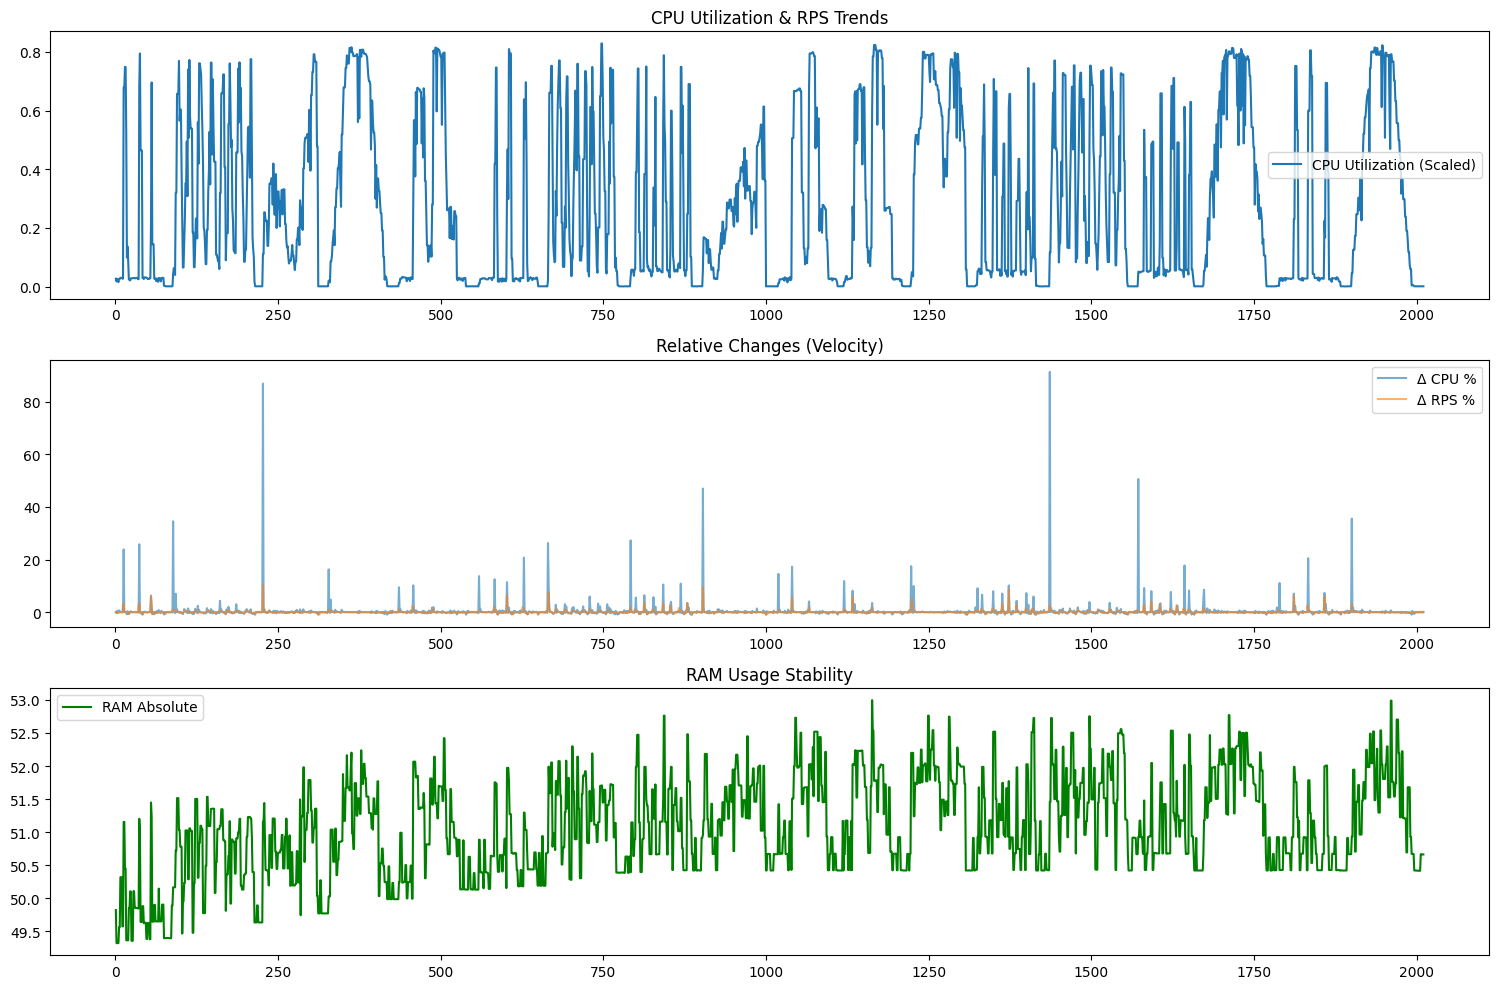

In [9]:
# 3. Візуалізація основних трендів
plt.figure(figsize=(15, 10))
plt.subplot(3, 1, 1)
plt.plot(df['cpu_utilization'], label='CPU Utilization (Scaled)')
plt.title('CPU Utilization & RPS Trends')
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(df['ptc_cpu'], alpha=0.6, label='Δ CPU %')
plt.plot(df['ptc_rps'], alpha=0.6, label='Δ RPS %')
plt.title('Relative Changes (Velocity)')
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(df['input_ram'], color='green', label='RAM Absolute')
plt.title('RAM Usage Stability')
plt.legend()
plt.tight_layout()

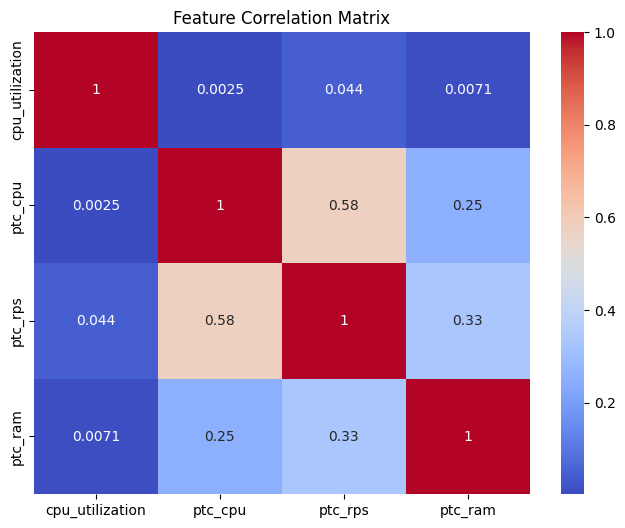

In [10]:
# 4. Кореляційна матриця (чи має сенс RAM?)
plt.figure(figsize=(8, 6))
sns.heatmap(df[['cpu_utilization', 'ptc_cpu', 'ptc_rps', 'ptc_ram']].corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.savefig('eda_correlation.png')

In [11]:
# 5. Аналіз RAM
print("RAM Stats:")
print(df['ptc_ram'].describe())

RAM Stats:
count    2010.000000
mean        0.000041
std         0.008106
min        -0.033983
25%         0.000000
50%         0.000000
75%         0.000000
max         0.041845
Name: ptc_ram, dtype: float64


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, ccf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [12]:
EPSILON = 1e-6 # Захист від ділення на нуль та log(0)

df['cpu_utilization'] = (df['input_cpu'] / 2000.0) # Переводимо в % від ліміту 2000m
df['rps_safe'] = df['input_rps'] + EPSILON
df['cpu_safe'] = df['cpu_utilization'] + EPSILON

In [13]:
# 2. Розрахунок Log Returns
# Формула: r_t = ln(P_t / P_{t-1})
df['log_ret_cpu'] = np.log(df['cpu_safe'] / df['cpu_safe'].shift(1))
df['log_ret_rps'] = np.log(df['rps_safe'] / df['rps_safe'].shift(1))

df = df.replace([np.inf, -np.inf], np.nan).dropna()

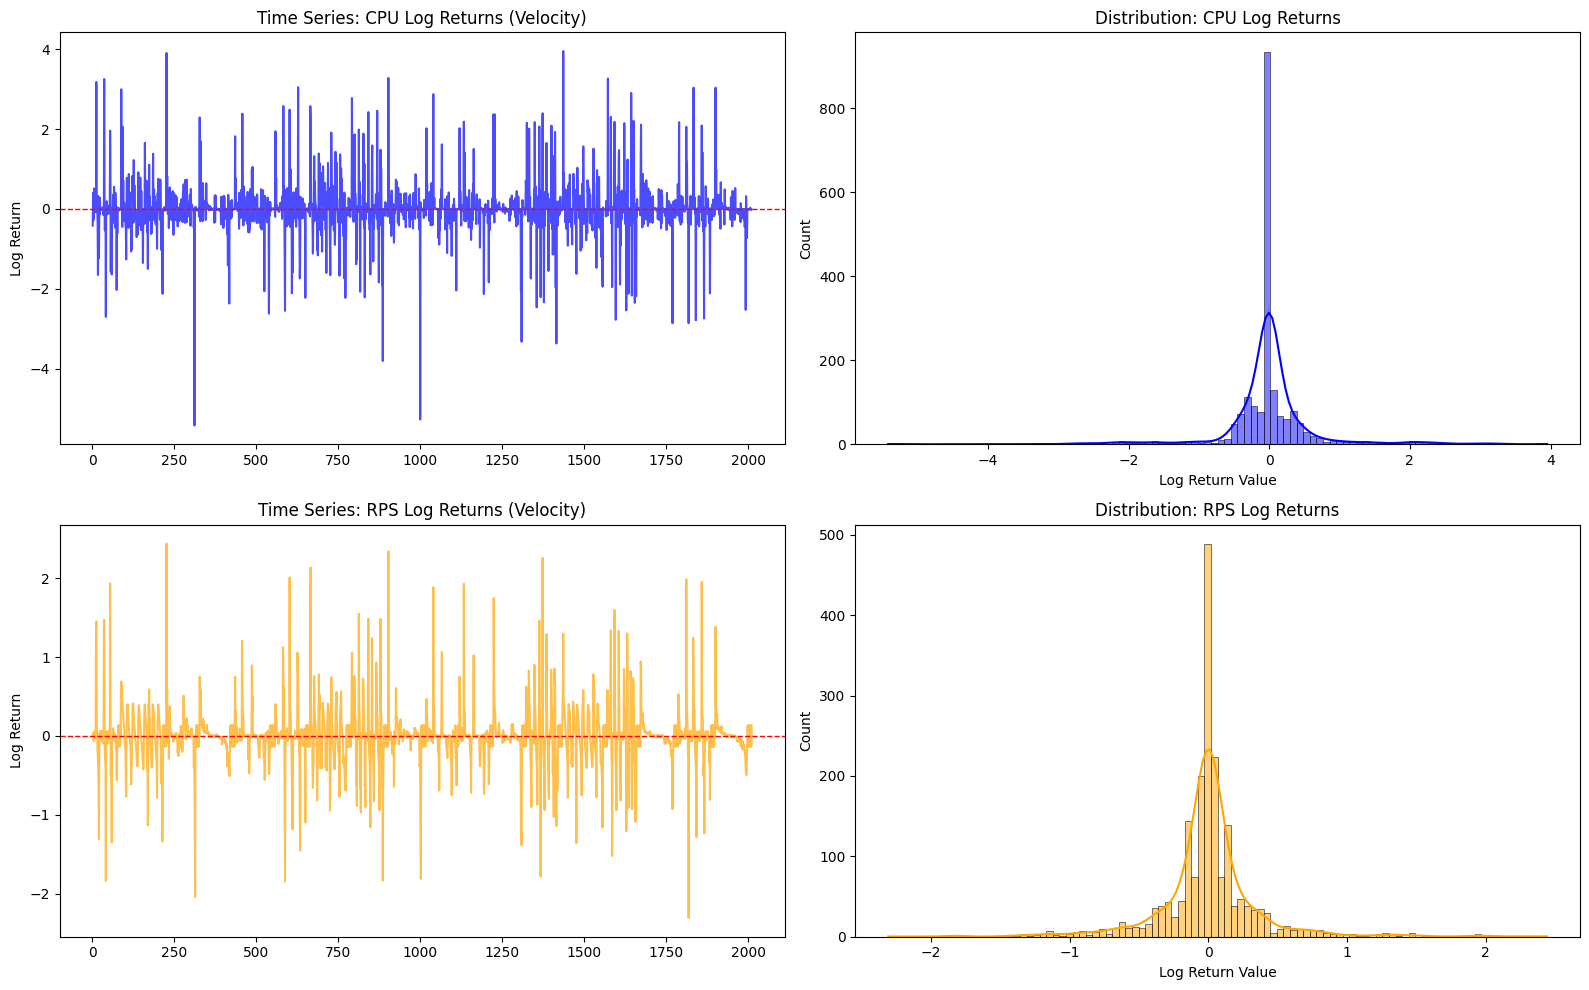

In [18]:
# ... (твій попередній код розрахунку log_ret_cpu та log_ret_rps) ...
# df = df.replace([np.inf, -np.inf], np.nan).dropna()

# --- ДОДАНИЙ БЛОК: Візуалізація Log Returns ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Графік коливань (Time Series) для CPU
axes[0, 0].plot(df.index, df['log_ret_cpu'], color='blue', alpha=0.7)
axes[0, 0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0, 0].set_title('Time Series: CPU Log Returns (Velocity)')
axes[0, 0].set_ylabel('Log Return')

# 2. Розподіл (Гістограма) для CPU
sns.histplot(df['log_ret_cpu'], bins=100, kde=True, ax=axes[0, 1], color='blue')
axes[0, 1].set_title('Distribution: CPU Log Returns')
axes[0, 1].set_xlabel('Log Return Value')

# 3. Графік коливань (Time Series) для RPS
axes[1, 0].plot(df.index, df['log_ret_rps'], color='orange', alpha=0.7)
axes[1, 0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1, 0].set_title('Time Series: RPS Log Returns (Velocity)')
axes[1, 0].set_ylabel('Log Return')

# 4. Розподіл (Гістограма) для RPS
sns.histplot(df['log_ret_rps'], bins=100, kde=True, ax=axes[1, 1], color='orange')
axes[1, 1].set_title('Distribution: RPS Log Returns')
axes[1, 1].set_xlabel('Log Return Value')

plt.tight_layout()
plt.savefig('eda_log_returns_visualized.png')
plt.show()
# ----------------------------------------------

In [15]:
# 3. ADF Test (Тест на стаціонарність)
def print_adf_test(series, name):
    result = adfuller(series.values)
    print(f"--- ADF Test for {name} ---")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4e}")
    if result[1] <= 0.05:
        print("Verdict: Data is STATIONARY (Reject H0)\n")
    else:
        print("Verdict: Data is NON-STATIONARY (Fail to reject H0)\n")

print_adf_test(df['cpu_utilization'], 'Raw CPU Utilization')
print_adf_test(df['log_ret_cpu'], 'Log Return CPU')
print_adf_test(df['log_ret_rps'], 'Log Return RPS')

--- ADF Test for Raw CPU Utilization ---
ADF Statistic: -6.9823
p-value: 8.1329e-10
Verdict: Data is STATIONARY (Reject H0)

--- ADF Test for Log Return CPU ---
ADF Statistic: -19.3141
p-value: 0.0000e+00
Verdict: Data is STATIONARY (Reject H0)

--- ADF Test for Log Return RPS ---
ADF Statistic: -10.7041
p-value: 3.4627e-19
Verdict: Data is STATIONARY (Reject H0)



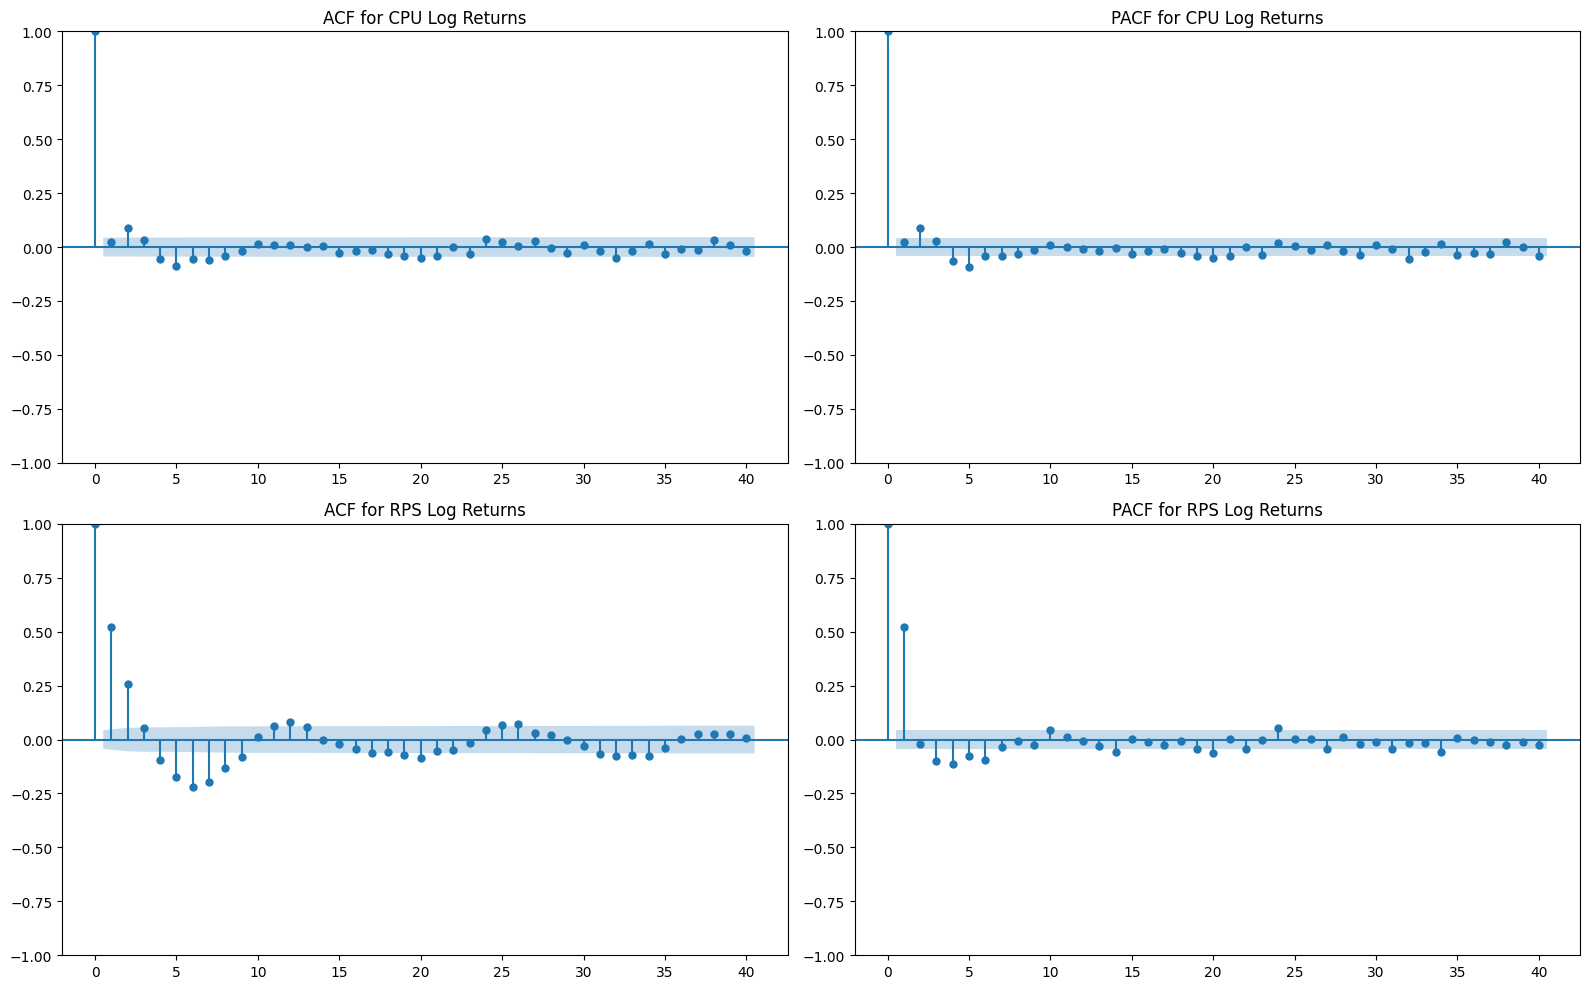

In [16]:
# 4. ACF та PACF (Аналіз вікна - Window Size)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

plot_acf(df['log_ret_cpu'], lags=40, ax=axes[0, 0], title='ACF for CPU Log Returns')
plot_pacf(df['log_ret_cpu'], lags=40, ax=axes[0, 1], title='PACF for CPU Log Returns')
plot_acf(df['log_ret_rps'], lags=40, ax=axes[1, 0], title='ACF for RPS Log Returns')
plot_pacf(df['log_ret_rps'], lags=40, ax=axes[1, 1], title='PACF for RPS Log Returns')

plt.tight_layout()
# plt.savefig('eda_acf_pacf.png')

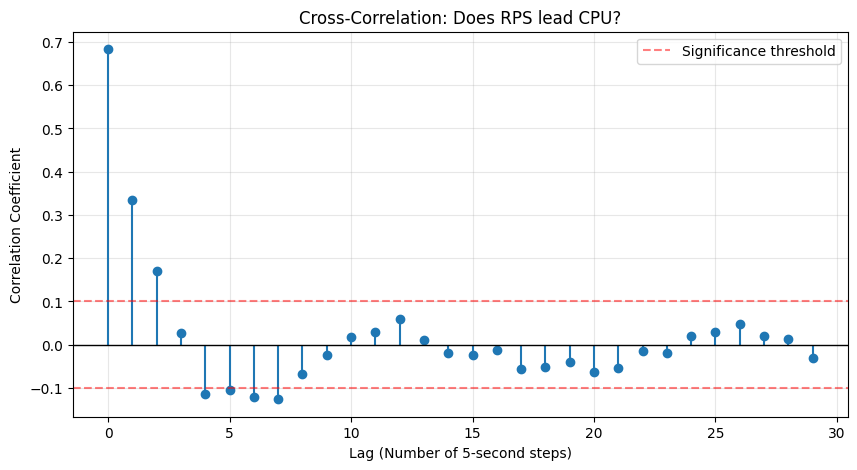

In [17]:
# 5. Cross-Correlation (Lag Analysis RPS -> CPU)
# Досліджуємо, як RPS випереджає CPU
lags = 30 # Дивимося на 30 кроків вперед і назад
cross_corr = ccf(df['log_ret_cpu'], df['log_ret_rps'], adjusted=False)

# Оскільки ccf() в statsmodels повертає тільки позитивні лаги (де RPS випереджає CPU),
# ми беремо перші 30 значень. Кожен крок - це твої 5 секунд.
plt.figure(figsize=(10, 5))
plt.stem(range(lags), cross_corr[:lags], basefmt=" ")
plt.axhline(0, color='black', linewidth=1)
plt.axhline(0.1, color='red', linestyle='--', alpha=0.5, label='Significance threshold')
plt.axhline(-0.1, color='red', linestyle='--', alpha=0.5)
plt.title('Cross-Correlation: Does RPS lead CPU?')
plt.xlabel('Lag (Number of 5-second steps)')
plt.ylabel('Correlation Coefficient')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('eda_cross_correlation.png')

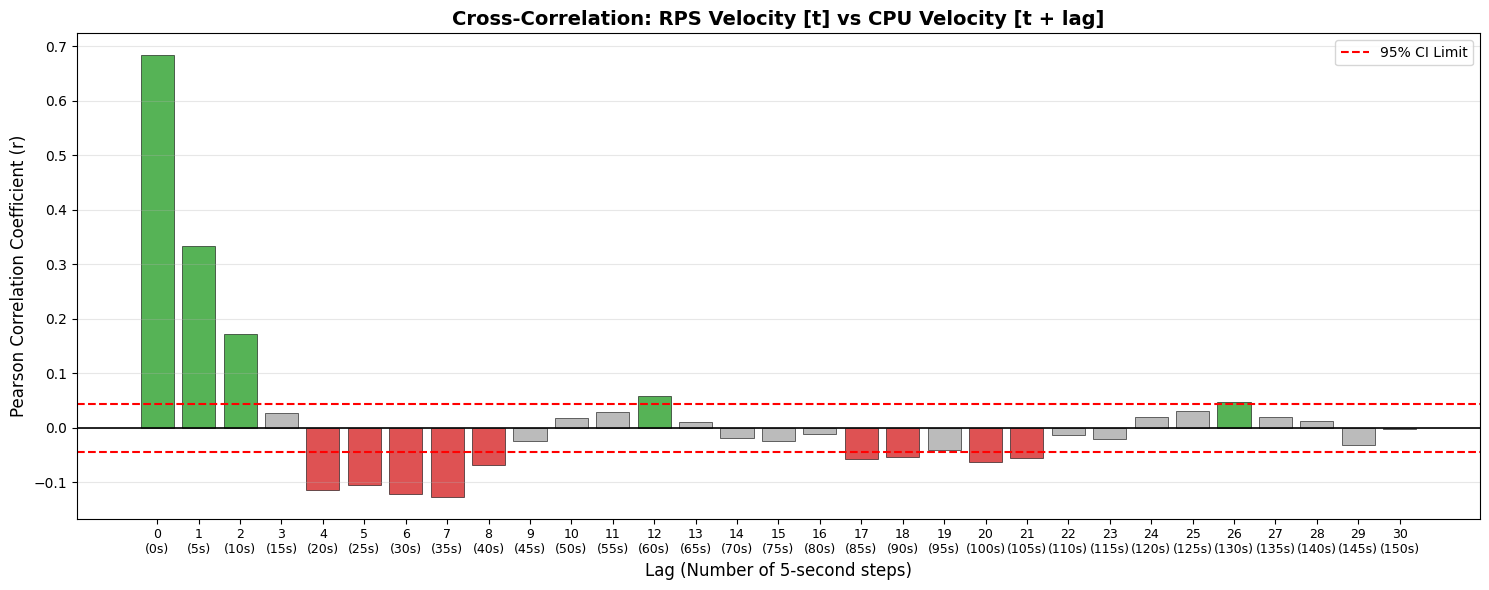

Peak correlation: r = 0.683 at lag = 0 steps (0s)


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Припускаємо, що df вже містить 'log_ret_rps' та 'log_ret_cpu'
# і ми вже видалили всі inf значення на попередніх етапах

# 1. Очищення даних від NaN (критично для розрахунку кореляції)
df_clean = df[['log_ret_rps', 'log_ret_cpu']].dropna()

max_lag = 30   # 30 × 5s = 150s

# 2. Нормалізація (Z-score)
# Хоча log returns вже центровані, Z-score робить їх ідеальними для Pearson r
rps_z = (df_clean['log_ret_rps'].values - df_clean['log_ret_rps'].mean()) / df_clean['log_ret_rps'].std()
cpu_z = (df_clean['log_ret_cpu'].values - df_clean['log_ret_cpu'].mean()) / df_clean['log_ret_cpu'].std()

# 3. Розрахунок крос-кореляції
lags = list(range(0, max_lag + 1))
xcorr = [
    np.corrcoef(rps_z[:len(rps_z) - lag] if lag else rps_z,
                cpu_z[lag:]               if lag else cpu_z)[0, 1]
    for lag in lags
]

# 4. Розрахунок 95% довірчого інтервалу (Confidence Interval)
ci = 1.96 / np.sqrt(len(rps_z))

# 5. Візуалізація
fig, ax = plt.subplots(figsize=(15, 6))

# Кольори: Зелений (значущий +), Червоний (значущий -), Сірий (незначущий/шум)
bar_colors = ["#2ca02c" if x > ci else ("#aaaaaa" if x > -ci else "#d62728") for x in xcorr]

ax.bar(lags, xcorr, color=bar_colors, alpha=0.8, edgecolor='black', linewidth=0.5)
ax.axhline( ci, color="red", linestyle="--", linewidth=1.5, label="95% CI Limit")
ax.axhline(-ci, color="red", linestyle="--", linewidth=1.5)
ax.axhline(0,   color="black", linewidth=1.2)

# Підписи осей та заголовки
ax.set_title("Cross-Correlation: RPS Velocity [t] vs CPU Velocity [t + lag]", fontsize=14, fontweight='bold')
ax.set_xlabel("Lag (Number of 5-second steps)", fontsize=12)
ax.set_ylabel("Pearson Correlation Coefficient (r)", fontsize=12)

# Налаштування поділок осі X (показуємо і лаг, і секунди)
ax.set_xticks(lags)
ax.set_xticklabels([f"{l}\n({l*5}s)" for l in lags], fontsize=9)

ax.legend(fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('eda_cross_correlation_bars.png', dpi=300)
plt.show()

# 6. Вивід найкращого лагу
best_lag = int(np.argmax(xcorr))
print(f"Peak correlation: r = {xcorr[best_lag]:.3f} at lag = {best_lag} steps ({best_lag * 5}s)")